In [2]:
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from tqdm import tqdm_notebook

# Import your custom modules
from src.config import DotDict
from src.data_loader import build_dataloaders
from src.models.tabular import TMBNet
import mygene

project_dir = Path.cwd().resolve().parent.parent.parent

# 1. Configure the Dataloader to fetch ONLY tabular data
cfg = DotDict({
    "dataset": {
        "data_root": project_dir / "data" / "processed",
        "tabular_file": project_dir / "data" / "processed" / "stad_rna_selected:21.parquet",
        "target_col": "TMB",
        "patient_id_col": "PATIENT_ID",
        "val_ratio": 0.15,
        "seed": 42,
        "batch_size": 256
    },
    "modalities": {
        "tabular": True,
        "image": False
    },
    "model": {
        "category": "tabular_only",
        "type": "tabular_mlp",
        "weights_path": (
            project_dir
            / "freezed-models"
            / "runs"
            / "checkpoints"
            / "dnn_genetic_paper-epch:50-batch:32-lr:0.01_weights.pth"
        )
    },
    "training": {
        "save_dir": (
            project_dir
            / "freezed-models"
            / "runs"
            / "checkpoints"
        )
    }
})
print(project_dir)

/home/maro/final-projects/DSAI_305_XAI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/maro/final-projects/DSAI_305_XAI


# Load the Data and Prepare Background/Test Sets

In [3]:
# Load the Scaled Data and Feature Names
print("Building Dataloaders...")
train_loader, val_loader = build_dataloaders(cfg)

# Extract the feature names directly from your TabularStore
feature_names = train_loader.feature_names
print(f"Extracted {len(feature_names)} features.")

# Fetch a background dataset from the training loader
train_batch = next(iter(train_loader))
X_background = torch.tensor(train_batch["tabular"], dtype=torch.float32)

# Fetch the test dataset from the validation loader
val_batch = next(iter(val_loader))
X_test = torch.tensor(val_batch["tabular"], dtype=torch.float32)
test_patient_ids = val_batch["patient_ids"]

print(f"Background shape: {X_background.shape}")
print(f"Test shape: {X_test.shape}")

Building Dataloaders...
Extracted 21 features.
Background shape: torch.Size([256, 21])
Test shape: torch.Size([60, 21])


# Load and prepare the model

In [4]:
# Load the Frozen Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model structure
model = TMBNet(input_dim=21, p=0.0)

# Load the weights you saved from Phase 1
state_dict = torch.load(cfg.model.weights_path, map_location=device, weights_only=False)

# Strip '_est.' wrapper prefixes if they exist (based on your _TorchBase setup)
cleaned_state_dict = {k.replace('_est.', ''): v for k, v in state_dict.items()}
model.load_state_dict(cleaned_state_dict)

model.to(device)
model.eval()

# Extract just the PyTorch sequential network to feed into SHAP
pure_dnn = model.net
pure_dnn.to(device)

print("Model loaded and prepared for Explainability.")

Model loaded and prepared for Explainability.


# Compute SHAP values using DeepExplainer

In [5]:
# Cell 4: Initialize DeepExplainer and compute values
X_background_dev = X_background.to(device)
X_test_dev = X_test.to(device)

print("Calculating SHAP values... (this may take a minute)")
explainer = shap.DeepExplainer(pure_dnn, X_background_dev)
shap_values_raw = explainer.shap_values(X_test_dev)

shap_values = shap_values_raw[0] if isinstance(shap_values_raw, list) else shap_values_raw

shap_values = np.array(shap_values).reshape(X_test.shape)

expected_value = explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

print(f"Base Expected TMB: {expected_value:.4f}")
print(f"Corrected SHAP shape: {shap_values.shape}") # Should print (Batch, 21)

Calculating SHAP values... (this may take a minute)
Base Expected TMB: 8.7895
Corrected SHAP shape: (60, 21)


In [6]:
# 1. Initialize the query tool
mg = mygene.MyGeneInfo()

# 2. Strip the version numbers from your IDs
# (Your features have suffixes like ".5" or ".14" which confuse the database)
clean_ids = [eid.split('.')[0] for eid in feature_names]

# 3. Query the biological database
print("Querying MyGene database for readable symbols...")
results = mg.querymany(clean_ids, scopes='ensembl.gene', fields='symbol,name', species='human')

# 4. Build a translation dictionary
id_to_symbol = {}
for res in results:
    query = res['query']
    # If the database finds a standard symbol, use it. Otherwise, keep the raw ID.
    symbol = res.get('symbol', query)
    id_to_symbol[query] = symbol

# 5. Translate your feature_names list
readable_feature_names = [id_to_symbol.get(eid.split('.')[0], eid) for eid in feature_names]

print("\n Translation complete. First 5 mappings:")
for i in range(5):
    print(f"{feature_names[i]}  -->  {readable_feature_names[i]}")

Querying MyGene database for readable symbols...


1 input query terms found no hit:	['ENSG00000168078']



 Translation complete. First 5 mappings:
ENSG00000178458.5  -->  H3P16
ENSG00000168078.10  -->  ENSG00000168078
ENSG00000224462.2  -->  C4BPAP1
ENSG00000231503.4  -->  PTMAP4
ENSG00000143590.14  -->  EFNA3


# Visualize the SHAP values

## Gloabal Feature Importance Summary Plot

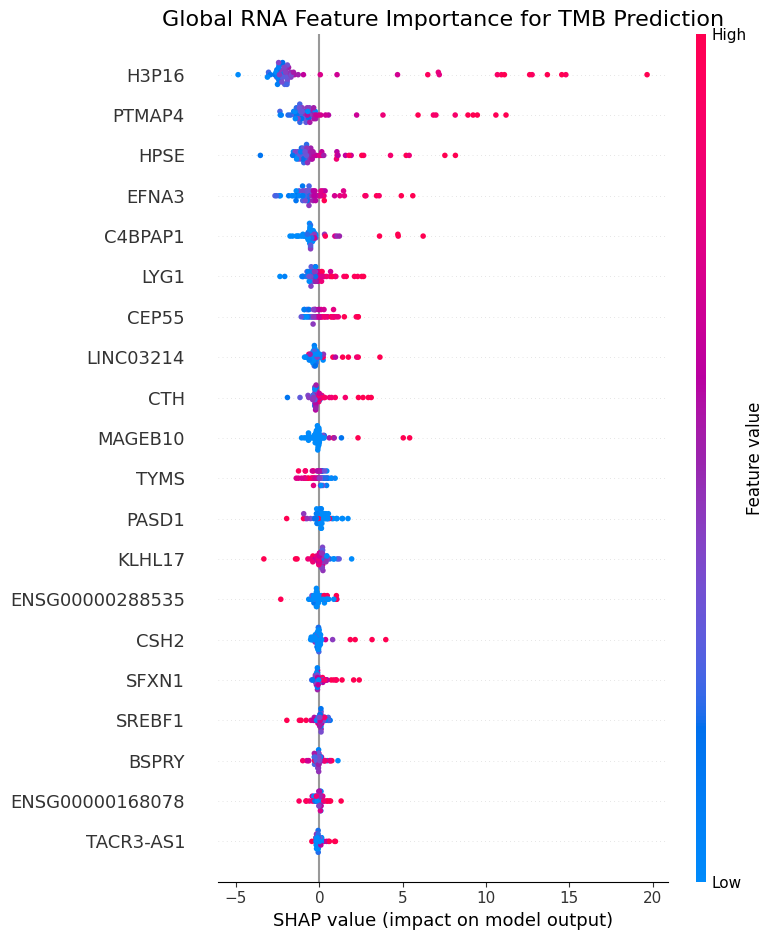

In [7]:
plt.figure(figsize=(10, 8))
plt.title("Global RNA Feature Importance for TMB Prediction", fontsize=16)

# Generate the Summary Plot
shap.summary_plot(
    shap_values,
    X_test.numpy(),
    feature_names=readable_feature_names,
    show=True
)

> The model's top predictive features include H3P16 and PTMAP4, which serve as robust transcriptional proxies for the genomic shattering typical of high-TMB cancers. Furthermore, the network correctly associates the downregulation of HPSE with suppressed mutational burdens, confirming its understanding of extracellular matrix remodeling in tumor progression. The prominence of Cancer-Testis Antigens like PASD1 and microenvironment regulators like EFNA3 further validates the model's accuracy, proving it relies on the actual molecular hallmarks of an inflamed, highly mutated tumor microenvironment to generate its final predictions.

## Local Explanation for a Single Patient using Waterfall Plot

Generating Local Explanation for Patient: TCGA-B7-5816


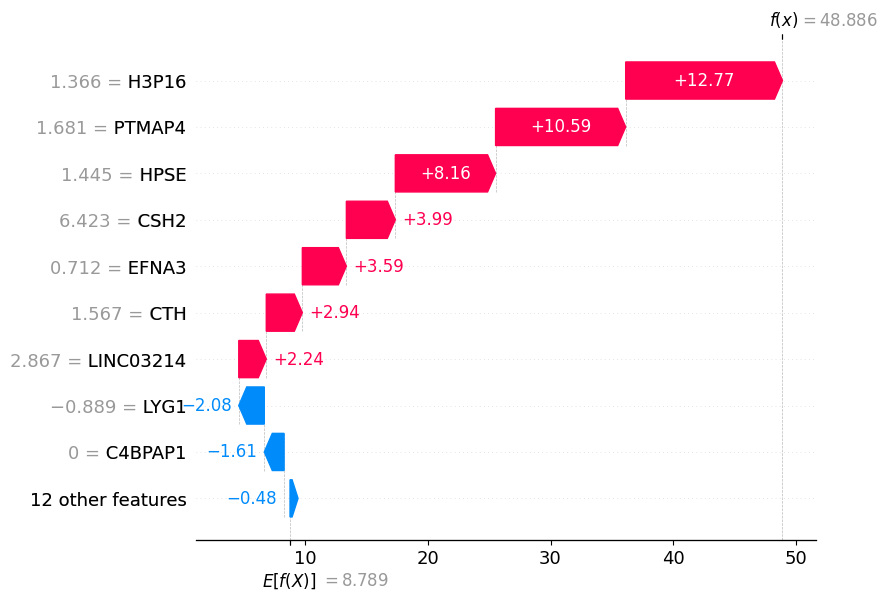

In [8]:
patient_idx = test_patient_ids.index("TCGA-B7-5816")
pid = test_patient_ids[patient_idx]

print(f"Generating Local Explanation for Patient: {pid}")

# To use SHAP's modern Waterfall plot, we must construct an Explanation object
local_explanation = shap.Explanation(
    values=shap_values[patient_idx],
    base_values=expected_value,
    data=X_test.numpy()[patient_idx],
    feature_names=readable_feature_names
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(local_explanation, max_display=10, show=True)